# Polymarket-calibrated scenario analysis

Our MC model gives ~85-90% P(TISZA largest) at current polls.  
Polymarket says **65%**.  
This notebook finds the poll scenario on the 65% iso-contour that is *closest* to current polls,
runs the full simulation there, and reports implied seats + transfer matrix.

In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

from lib.config import SimConfig
from lib.transfer_model import (
    Q_PRIOR, load_baseline_and_matrix, load_nowcast,
    calibrate_transfer_matrix, run_simulation, aggregate_results,
)
from lib.reports import (
    plot_seat_distributions, plot_seat_scatter, plot_transfer_matrix,
    print_seat_summary, print_outcome_probabilities,
)
from poll_sensitivity_heatmap import build_shares, compute_grid, MINOR_KEYS

TARGET_PROB = 65.0   # Polymarket TISZA win probability to match
N_SIM = 5000
GRID_NPZ = 'output/sensitivity_grid.npz'

In [2]:
if Path(GRID_NPZ).exists():
    d = np.load(GRID_NPZ)
    grid = d['grid']
    fidesz_vals = d['fidesz_vals']
    tisza_vals = d['tisza_vals']
    minor_shares = {k: float(d[f'minor_{k}']) for k in MINOR_KEYS}
    print(f'Loaded grid {grid.shape} from {GRID_NPZ}')
    print('Minor shares:', {k: f'{v*100:.2f}%' for k, v in minor_shares.items()})
else:
    print('Grid not found -- computing (may take 20-30 min)...')
    V22, districts = load_baseline_and_matrix()
    nowcast_shares, _, _ = load_nowcast()
    minor_shares = {k: nowcast_shares[k] for k in MINOR_KEYS}
    step = 1 / 100
    fidesz_vals = np.arange(0.33, 0.49, step)
    tisza_vals  = np.arange(0.40, 0.56, step)
    cfg_grid = SimConfig(n_sim=200, seed=2026)
    grid = compute_grid(V22, districts, minor_shares, fidesz_vals, tisza_vals, cfg_grid)
    Path('output').mkdir(exist_ok=True)
    np.savez(GRID_NPZ, grid=grid, fidesz_vals=fidesz_vals, tisza_vals=tisza_vals,
             **{f'minor_{k}': v for k, v in minor_shares.items()})
    print(f'Grid computed and saved to {GRID_NPZ}')

Grid not found -- computing (may take 20-30 min)...
  Nowcast: raw sum 0.9999 -> renormalized to 1.0 (decided shares)
  [  1/272] F=33.0%  T=40.0%  ...   WARNING: calibration max error = 0.69 pp (threshold 0.5 pp)
TISZA 92.5%
  [  2/272] F=34.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
TISZA 85.0%
  [  3/272] F=35.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
TISZA 76.0%
  [  4/272] F=36.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
TISZA 66.5%
  [  5/272] F=37.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
TISZA 66.0%
  [  6/272] F=38.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
TISZA 52.0%
  [  7/272] F=39.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
Fidesz 51.0%
  [  8/272] F=40.0%  T=40.0%  ...   WARNING: calibration max error = 0.70 pp (threshold 0.5 pp)
Fidesz 66.5%
  [  9/272] F=41

In [3]:
# Use matplotlib contour to get smooth interpolated iso-contour at TARGET_PROB
fig, ax = plt.subplots()
cs = ax.contour(fidesz_vals * 100, tisza_vals * 100, grid, levels=[TARGET_PROB])
plt.close(fig)

# Extract all contour (x, y) points and find closest to current polls
nowcast_shares_now, nowcast_se, _ = load_nowcast()
cur_f = nowcast_shares_now['Fidesz26'] * 100
cur_t = nowcast_shares_now['TISZA26'] * 100

all_pts = np.vstack(cs.allsegs[0])   # shape (N, 2): col0=Fidesz%, col1=TISZA%
dists = np.hypot(all_pts[:, 0] - cur_f, all_pts[:, 1] - cur_t)
idx = np.argmin(dists)
cal_f_pct, cal_t_pct = all_pts[idx]

print(f'Current polls:       Fidesz={cur_f:.2f}%  TISZA={cur_t:.2f}%')
print(f'Calibrated point:    Fidesz={cal_f_pct:.2f}%  TISZA={cal_t_pct:.2f}%')
print(f'Distance from polls: {dists[idx]:.2f} pp')
print(f'Grid says P(TISZA) ~ {TARGET_PROB}% at this point')

  Nowcast: raw sum 0.9999 -> renormalized to 1.0 (decided shares)
Current polls:       Fidesz=39.64%  TISZA=47.29%
Calibrated point:    Fidesz=42.00%  TISZA=45.73%
Distance from polls: 2.83 pp
Grid says P(TISZA) ~ 65.0% at this point


In [4]:
# Heatmap with current polls (gold star) and calibrated point (red circle) marked
FIDESZ_ORANGE = '#F4831F'
TISZA_BLUE    = '#003F87'

import matplotlib.colors as mcolors
colors_list = [FIDESZ_ORANGE, '#FFFFFF', TISZA_BLUE]
cmap = mcolors.LinearSegmentedColormap.from_list('FideszTISZA', colors_list, N=512)

f_step = float(fidesz_vals[1] - fidesz_vals[0]) if len(fidesz_vals) > 1 else 0.01
t_step = float(tisza_vals[1] - tisza_vals[0])  if len(tisza_vals)  > 1 else 0.01
extent = [
    fidesz_vals[0]*100 - f_step*50,
    fidesz_vals[-1]*100 + f_step*50,
    tisza_vals[0]*100 - t_step*50,
    tisza_vals[-1]*100 + t_step*50,
]

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, origin='lower',
               extent=extent, aspect='auto', interpolation='bilinear')

X = fidesz_vals * 100
Y = tisza_vals * 100
try:
    CS50 = ax.contour(X, Y, grid, levels=[50],
                      colors=['#333333'], linewidths=[2.5], linestyles=['-'])
    ax.clabel(CS50, inline=True, fontsize=10, fmt='50%% toss-up')
    CS65 = ax.contour(X, Y, grid, levels=[TARGET_PROB],
                      colors=['red'], linewidths=[2.0], linestyles=['--'])
    ax.clabel(CS65, inline=True, fontsize=10, fmt=f'{TARGET_PROB:.0f}%% Polymarket')
    CS_t = ax.contour(X, Y, grid, levels=[75, 90],
                      colors=[TISZA_BLUE, TISZA_BLUE],
                      linewidths=[1.4, 1.0], linestyles=['--', ':'])
    ax.clabel(CS_t, inline=True, fontsize=8, fmt=lambda v: f'T {v:.0f}%')
    CS_f = ax.contour(X, Y, grid, levels=[25, 10],
                      colors=[FIDESZ_ORANGE, FIDESZ_ORANGE],
                      linewidths=[1.4, 1.0], linestyles=['--', ':'])
    ax.clabel(CS_f, inline=True, fontsize=8, fmt=lambda v: f'F {100-v:.0f}%')
except Exception as e:
    print(f'Contour warning: {e}')

# Gold star = current polls
ax.plot(cur_f, cur_t, marker='*', markersize=22, color='gold',
        markeredgecolor='black', markeredgewidth=1.3, zorder=10, linestyle='none',
        label=f'Current polls  F={cur_f:.1f}%  T={cur_t:.1f}%')

# Red circle = calibrated 65% point
ax.plot(cal_f_pct, cal_t_pct, marker='o', markersize=14, color='red',
        markeredgecolor='black', markeredgewidth=1.3, zorder=10, linestyle='none',
        label=f'Calibrated ({TARGET_PROB:.0f}% Polymarket)  F={cal_f_pct:.1f}%  T={cal_t_pct:.1f}%')

ax.set_xlabel('Fidesz vote share (%)', fontsize=13, labelpad=8)
ax.set_ylabel('TISZA vote share (%)', fontsize=13, labelpad=8)
ax.set_title('Sensitivity heatmap with Polymarket-calibrated scenario',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xticks(fidesz_vals * 100)
ax.set_yticks(tisza_vals * 100)
ax.set_xticklabels([f'{v*100:.1f}%' for v in fidesz_vals], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([f'{v*100:.1f}%' for v in tisza_vals], fontsize=8)
cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label('P(TISZA largest party)', fontsize=10)
cbar.set_ticks([0, 25, 50, 65, 75, 100])
cbar.set_ticklabels(['Fidesz certain', 'F 75%', 'Toss-up', '65% (Polymarket)', 'T 75%', 'TISZA certain'])
ax.legend(loc='upper right', fontsize=10, framealpha=0.92)
plt.tight_layout()

Path('output/plots').mkdir(parents=True, exist_ok=True)
fig.savefig('output/plots/calibrated_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: output/plots/calibrated_heatmap.png')

Contour warning: Contour levels must be increasing
Saved: output/plots/calibrated_heatmap.png


C:\Users\takat\AppData\Local\Temp\ipykernel_37240\2464065582.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [5]:
cal_f_raw = cal_f_pct / 100.0
cal_t_raw = cal_t_pct / 100.0
shares_cal = build_shares(cal_f_raw, cal_t_raw, minor_shares)
flat_se = {k: 0.02 for k in ['Fidesz26', 'TISZA26'] + MINOR_KEYS}

V22, districts = load_baseline_and_matrix()
print('Calibrated vote shares (renormalized to sum to 1):')
for k, v in shares_cal.items():
    print(f'  {k}: {v*100:.2f}%')
print(f'  TOTAL: {sum(shares_cal.values())*100:.2f}%')

Calibrated vote shares (renormalized to sum to 1):
  Fidesz26: 41.67%
  TISZA26: 45.37%
  MH26: 6.00%
  MKKP26: 3.31%
  Bal26: 3.47%
  Other26: 0.17%
  TOTAL: 100.00%


In [6]:
cfg = SimConfig(n_sim=N_SIM, seed=2026)
Q_cal = calibrate_transfer_matrix(V22, shares_cal, flat_se, Q_PRIOR, cfg.lam_prior)
print('Transfer matrix calibrated.')

Transfer matrix calibrated.


In [7]:
sim_results = run_simulation(V22, Q_cal, districts, cfg, verbose=True)
agg = aggregate_results(sim_results)
print_seat_summary(agg)
print_outcome_probabilities(agg)

Simulating:   0%|          | 0/5000 [00:00<?, ?it/s]

  SEAT PROJECTION  (5,000 simulations)
  Party             OEVK med  List med  Total med    5th%   95th%   P(>0)
  ------------------------------------------------------------------------
  Fidesz-KDNP            48        42         89      60     111     100%
  TISZA                  58        43        102      80     131     100%
  Baloldal                0         0          0       0       6      10%
  Mi Hazank               0         7          7       0       9      82%
  MKKP                    0         0          0       0       6       5%
  Other/EM                0         0          0       0       0       0%
  ------------------------------------------------------------------------
  Draw total (med)                           199     199     199    (should be ~199)
  OUTCOME PROBABILITIES
  TISZA largest party:             65.1%
  TISZA majority (>=100 seats):    55.5%
  Fidesz largest party:            33.4%
  Fidesz majority (>=100 seats):   24.3%
  Fidesz supermajori

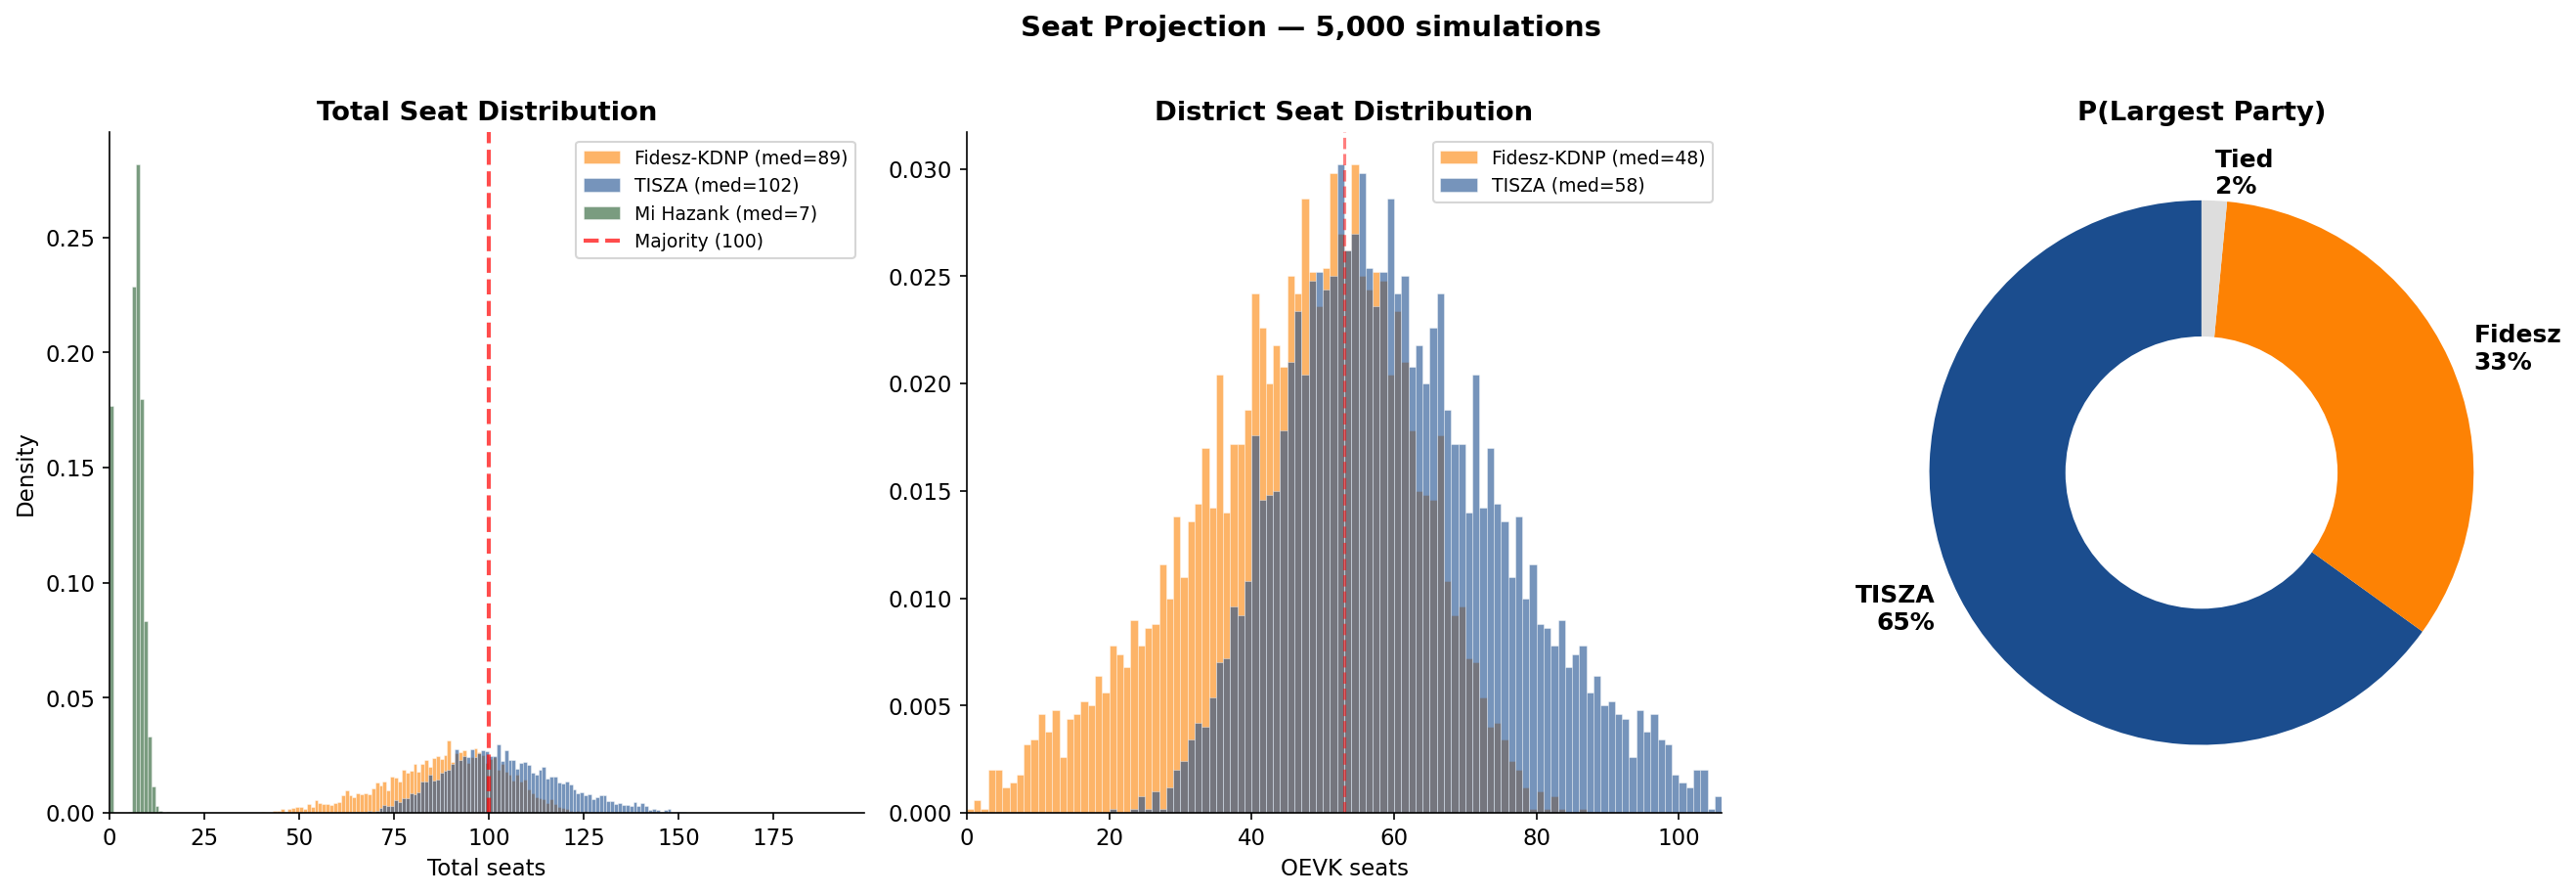

In [8]:
path = plot_seat_distributions(agg, out_path='output/plots/calibrated_seat_dist.png')
from IPython.display import Image
Image(path)

In [15]:
# Calculate probability mass for TISZA in 100-109 seats (inclusive)
tisza_seats = agg['total_seats']['TISZA']
prob_mass_100_109 = np.mean((tisza_seats >= 100) & (tisza_seats <= 109))
print(f"Probability mass for TISZA in 100-109 seats (inclusive): {prob_mass_100_109:.4f} ({prob_mass_100_109*100:.2f}%)")

Probability mass for TISZA in 100-109 seats (inclusive): 0.2378 (23.78%)


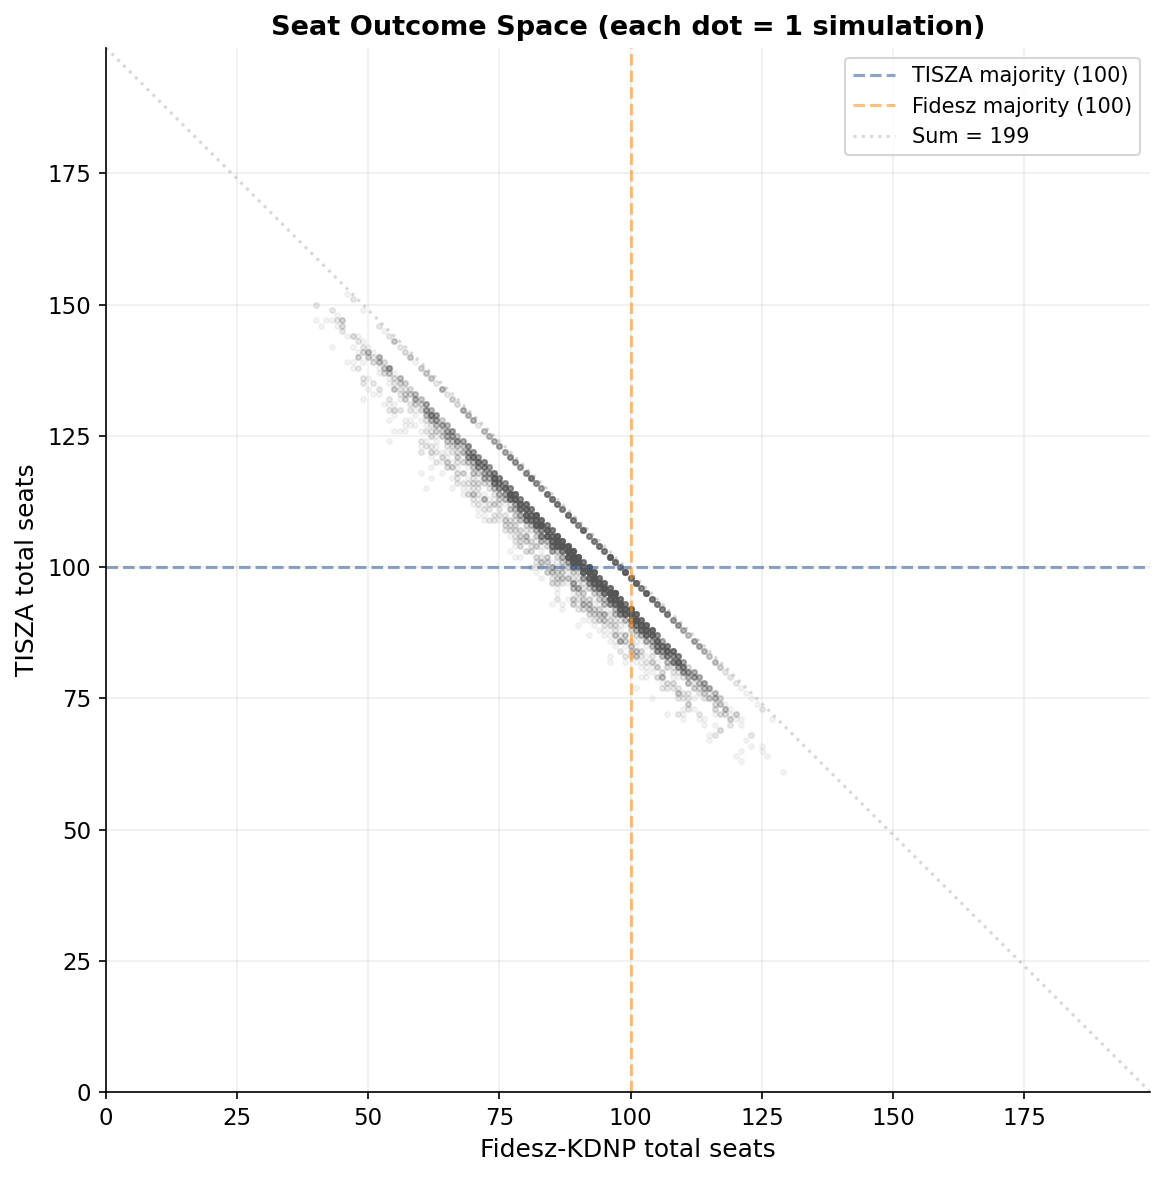

In [9]:
path = plot_seat_scatter(agg, out_path='output/plots/calibrated_seat_scatter.png')
from IPython.display import Image
Image(path)

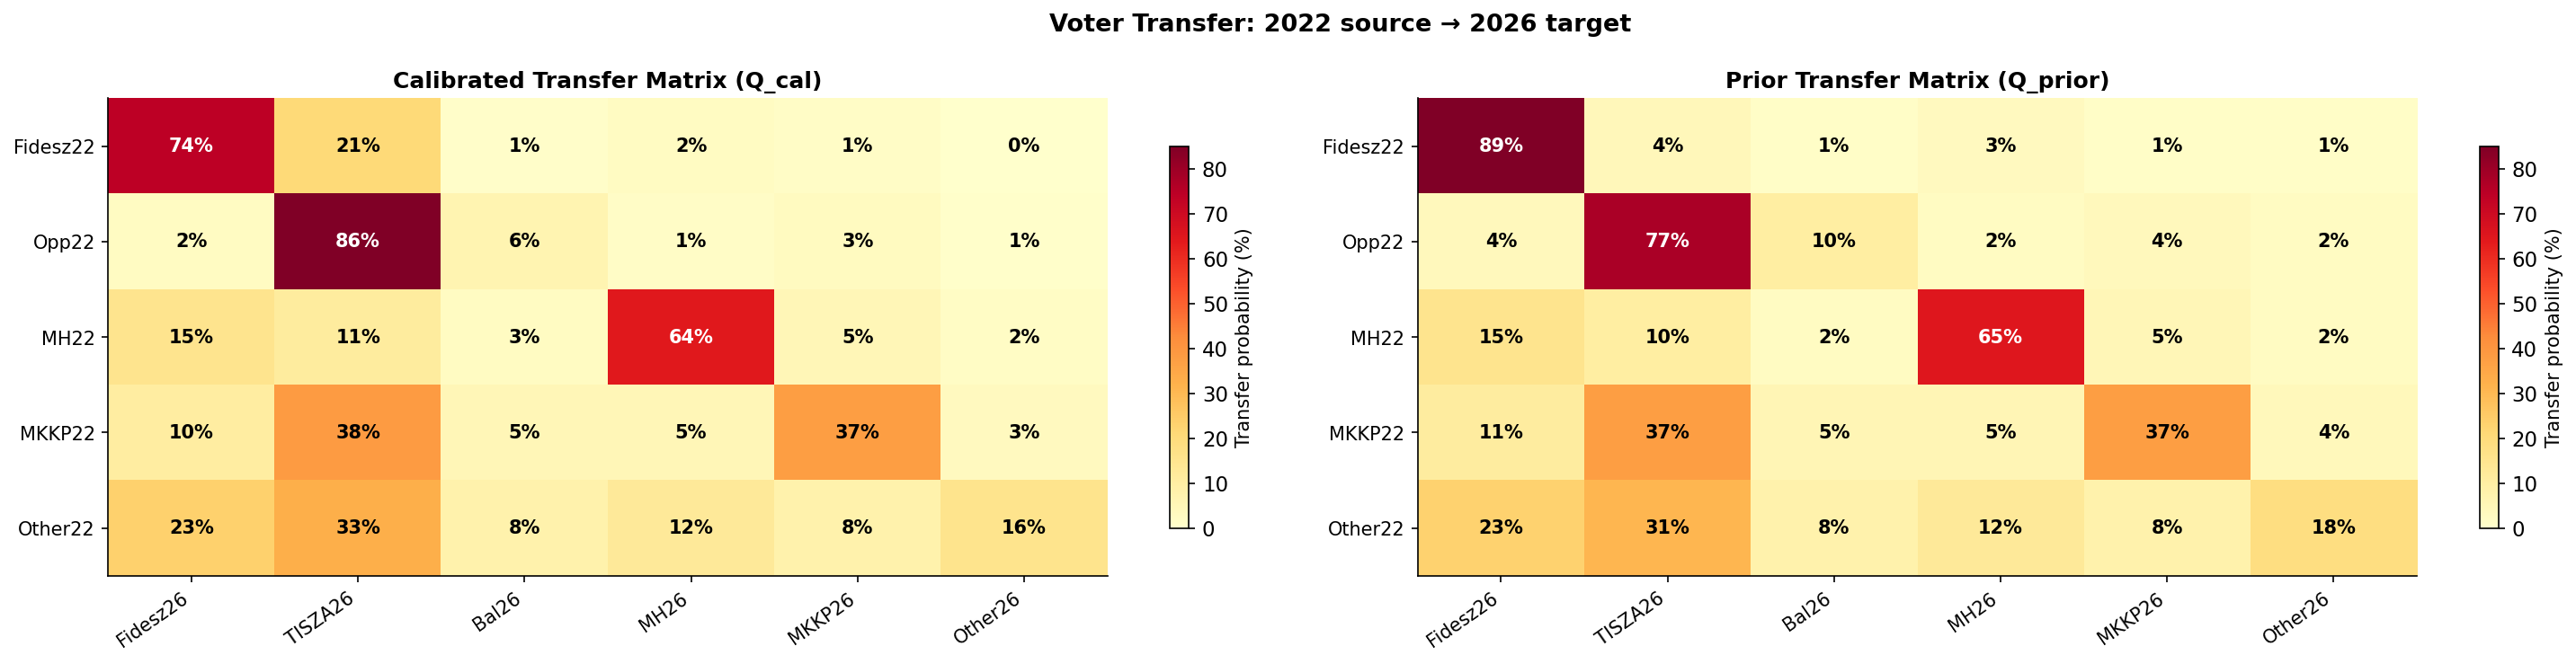

In [10]:
path = plot_transfer_matrix(Q_cal, Q_PRIOR, out_path='output/plots/calibrated_transfer_matrix.png')
from IPython.display import Image
Image(path)